In [142]:
#Importación de librerías
import numpy as np
import pandas as pd
from statistics import mode
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [192]:
# Leer el archivo Excel en un DataFrame
df = pd.read_excel("data_Leads enero-julio 2025.xlsx")

In [193]:
# Mostrar las primeras filas para verificar que se cargó correctamente
print(df.head())

   N°          Fecha Creación Usuario Creador Tipo Persona   Apellidos  \
0   1 2025-01-01 13:39:43.297               -      natural        G.E.   
1   2 2025-01-01 13:49:45.140               -      natural    lusquiño   
2   3 2025-01-01 14:55:06.221               -      natural  Villanueva   
3   4 2025-01-01 15:18:47.430               -      natural      Monzon   
4   5 2025-01-01 15:20:26.013               -      natural   Rodriguez   

          Nombres Tipo Documento Nº Documento Genero Estado Civil  ...  \
0         Edgardo            DNI     44073153    NaN          NaN  ...   
1         ernesto            DNI     47972622    NaN          NaN  ...   
2            Luis            DNI     43156237    NaN          NaN  ...   
3  Brandy Aguilar            DNI     72350832    NaN          NaN  ...   
4           Oscar            DNI     71243562    NaN          NaN  ...   

  dni_apoderado direccion_contacto_alternativo es_su_primera_vivienda  \
0           NaN                      

In [194]:
# Ver las columnas del DataFrame
df.columns

Index(['N°', 'Fecha Creación', 'Usuario Creador', 'Tipo Persona', 'Apellidos',
       'Nombres', 'Tipo Documento', 'Nº Documento', 'Genero', 'Estado Civil',
       ...
       'dni_apoderado', 'direccion_contacto_alternativo',
       'es_su_primera_vivienda',
       'en_que_area_del_departamento_cree_usted_que_optimizamos_el_metro_cuadrado',
       'genero_musical', 'telefono_familiar', 'relacion',
       'Cliente Clasifica PEP', 'Teléfono fijo del centro de trabajo',
       'Teléfono celular del centro de trabajo'],
      dtype='object', length=101)

In [195]:
# 5. Mostrar información general del DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9672 entries, 0 to 9671
Columns: 101 entries, N° to Teléfono celular del centro de trabajo
dtypes: datetime64[ns](4), float64(2), int64(2), object(93)
memory usage: 7.5+ MB
None


1. TIPO DE FINANCIAMIENTO VS PROYECTOS RELACIONADOS EN BASE AL NIVEL DE INTERES

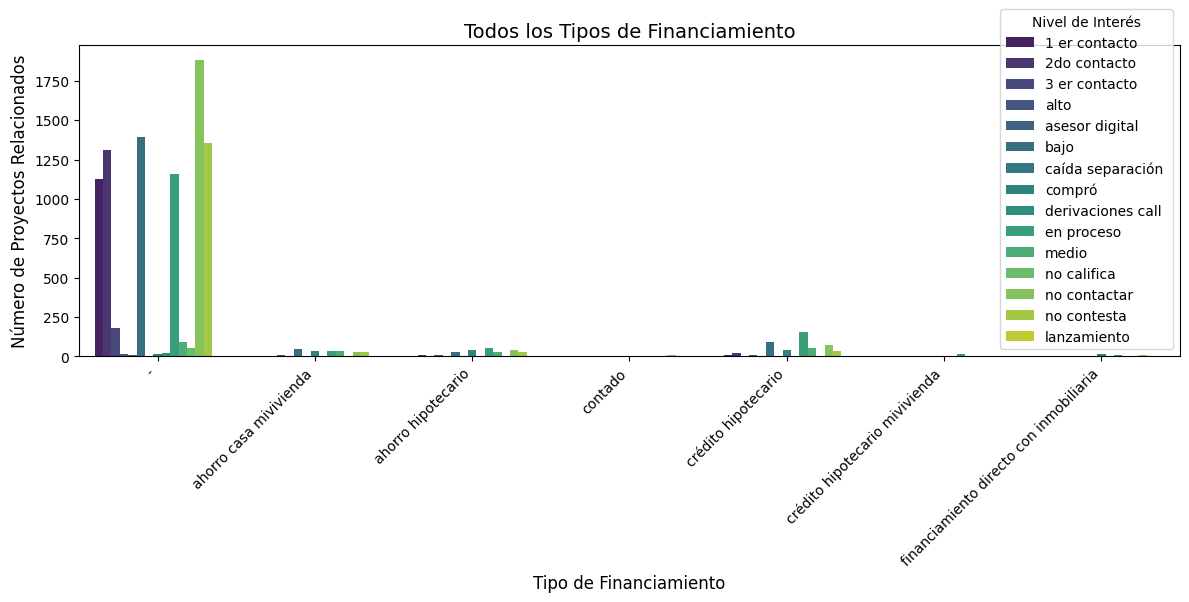

In [196]:
# =========================
# 1. Gráfico del Tipo de Financiamiento vs Proyectos Relacionados en base al nivel de interes considerando todos los valores (incluyendo las filas que contengan valores nulos)
# =========================
conteo_todos = df.groupby(["Tipo de Financiamiento", "Nivel De Interes"]).size().reset_index(name="Proyectos Relacionados")

plt.figure(figsize=(12,6))
sns.barplot(data=conteo_todos,
            x="Tipo de Financiamiento",
            y="Proyectos Relacionados",
            hue="Nivel De Interes",
            palette="viridis")

plt.title("Todos los Tipos de Financiamiento", fontsize=14)
plt.xlabel("Tipo de Financiamiento", fontsize=12)
plt.ylabel("Número de Proyectos Relacionados", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nivel de Interés")
plt.tight_layout()
plt.show()

In [197]:
# Variable que contiene todos los valores del Tipo de Financiamiento
conteo_todos

,Tipo de Financiamiento,Nivel De Interes,Proyectos Relacionados
0,-,1 er contacto,1127
1,-,2do contacto,1313
2,-,3 er contacto,181
3,-,alto,13
4,-,asesor digital,6
...,...,...,...
70,financiamiento directo con inmobiliaria,compró,13
71,financiamiento directo con inmobiliaria,en proceso,6
72,financiamiento directo con inmobiliaria,medio,5
73,financiamiento directo con inmobiliaria,no contactar,7


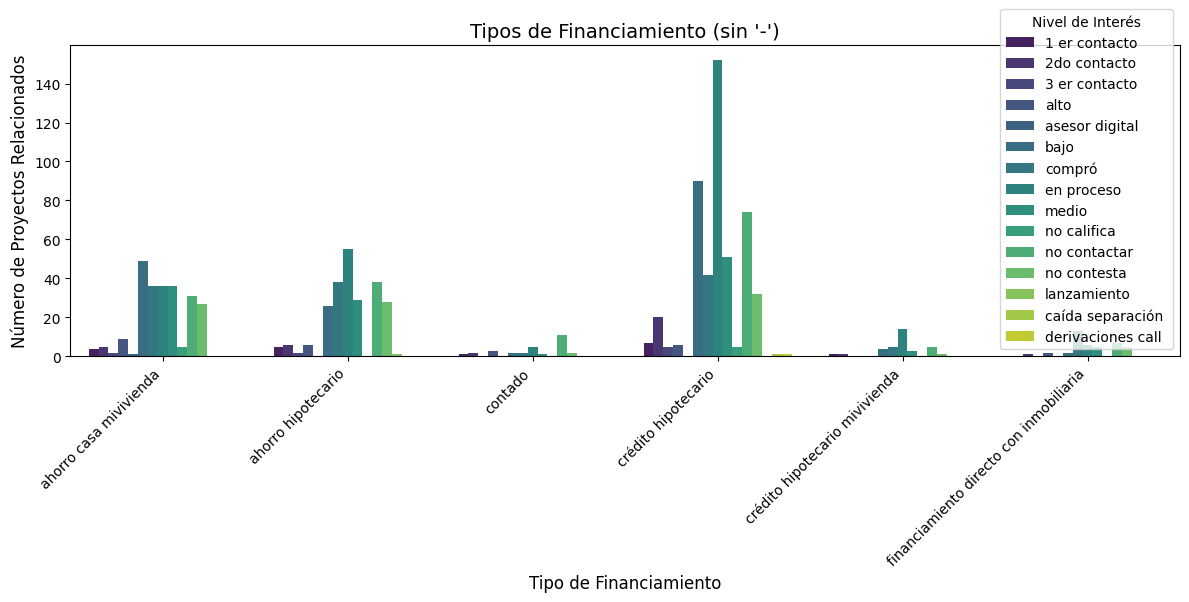

In [198]:
# =========================
# 2. Gráfico del Tipo de Financiamiento vs Proyectos Relacionados en base al nivel de interes considerando todos los valores (incluyendo las filas que contengan valores nulos)
#    Sin considerar el valor "-" de la columna Tipo de Financiamiento
# =========================
df_sin = df[df["Tipo de Financiamiento"] != "-"]

conteo_sin = df_sin.groupby(["Tipo de Financiamiento", "Nivel De Interes"]).size().reset_index(name="Proyectos Relacionados")

plt.figure(figsize=(12,6))
sns.barplot(data=conteo_sin,
            x="Tipo de Financiamiento",
            y="Proyectos Relacionados",
            hue="Nivel De Interes",
            palette="viridis")

plt.title("Tipos de Financiamiento (sin '-')", fontsize=14)
plt.xlabel("Tipo de Financiamiento", fontsize=12)
plt.ylabel("Número de Proyectos Relacionados", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nivel de Interés")
plt.tight_layout()
plt.show()

In [199]:
# Variable que contiene todos los valores del Tipo de Financiamiento, menos el valor "-"
conteo_sin

,Tipo de Financiamiento,Nivel De Interes,Proyectos Relacionados
0,ahorro casa mivivienda,1 er contacto,4
1,ahorro casa mivivienda,2do contacto,5
2,ahorro casa mivivienda,3 er contacto,2
3,ahorro casa mivivienda,alto,9
4,ahorro casa mivivienda,asesor digital,1
...,...,...,...
56,financiamiento directo con inmobiliaria,compró,13
57,financiamiento directo con inmobiliaria,en proceso,6
58,financiamiento directo con inmobiliaria,medio,5
59,financiamiento directo con inmobiliaria,no contactar,7


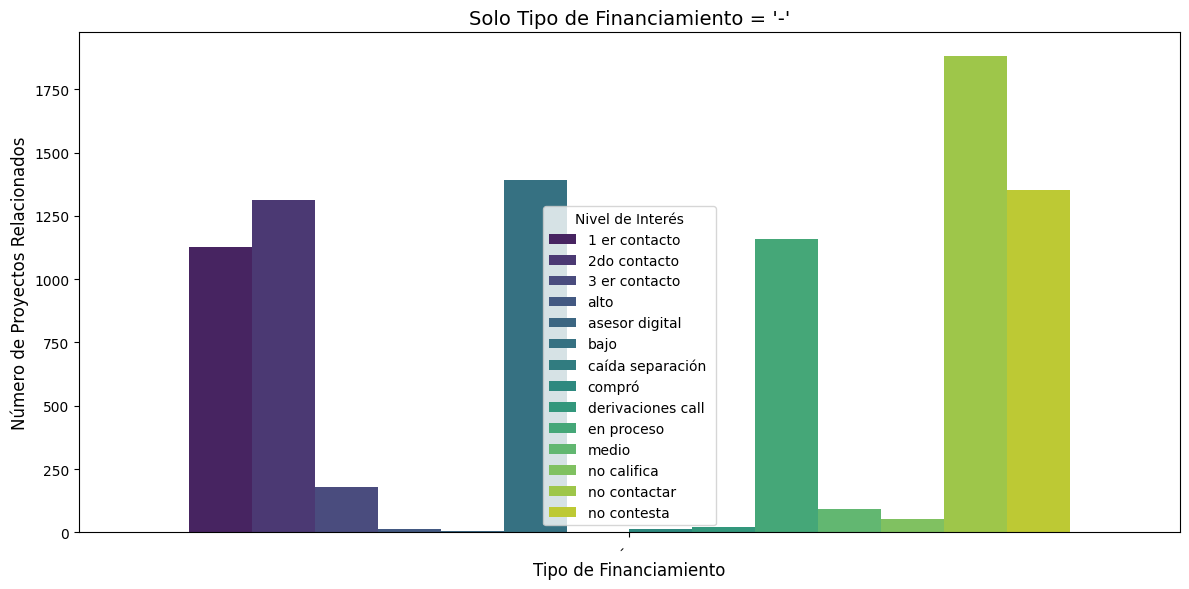

In [200]:
# =========================
# 3. Gráfico del Tipo de Financiamiento vs Proyectos Relacionados en base al nivel de interes considerando todos los valores (incluyendo las filas que contengan valores nulos)
#    Solo considera el valor "-" de la columna Tipo de Financiamiento
# =========================
df_solo = df[df["Tipo de Financiamiento"] == "-"]

conteo_solo = df_solo.groupby(["Tipo de Financiamiento", "Nivel De Interes"]).size().reset_index(name="Proyectos Relacionados")

plt.figure(figsize=(12,6))
sns.barplot(data=conteo_solo,
            x="Tipo de Financiamiento",
            y="Proyectos Relacionados",
            hue="Nivel De Interes",
            palette="viridis")

plt.title("Solo Tipo de Financiamiento = '-'", fontsize=14)
plt.xlabel("Tipo de Financiamiento", fontsize=12)
plt.ylabel("Número de Proyectos Relacionados", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nivel de Interés")
plt.tight_layout()
plt.show()


In [201]:
# Variable que contiene solo considera el valor "-" del Tipo de Financiamiento
conteo_solo

,Tipo de Financiamiento,Nivel De Interes,Proyectos Relacionados
0,-,1 er contacto,1127
1,-,2do contacto,1313
2,-,3 er contacto,181
3,-,alto,13
4,-,asesor digital,6
5,-,bajo,1393
6,-,caída separación,1
7,-,compró,14
8,-,derivaciones call,21
9,-,en proceso,1158


2. AREA COMUN MAS VALORADA VS NIVEL DE INTERES EN BASE A LOS PROYECTOS RELACIONADOS

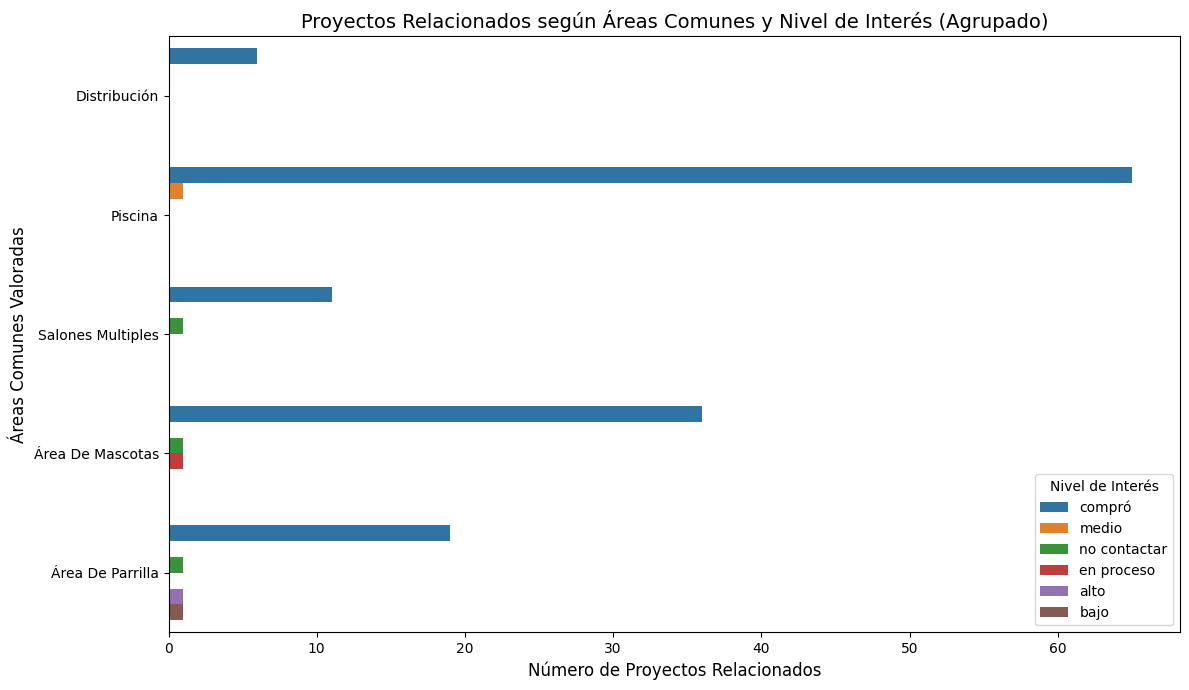

In [204]:
# Se agrupa las areas comunes que les gusto respecto al nivel de interes y se realiza un conteo en base al numero de Proyectos Relacionados
conteo = df.groupby(["que_le_gusto_de_las_areas_comunes", "Nivel De Interes"])["Proyectos Relacionados"].count().reset_index()

# Gráfico de barras horizontal agrupado
plt.figure(figsize=(12,7))
sns.barplot(
    data=conteo,
    y="que_le_gusto_de_las_areas_comunes",
    x="Proyectos Relacionados",
    hue="Nivel De Interes",
    orient="h",
    dodge=True
)

plt.title("Proyectos Relacionados según Áreas Comunes y Nivel de Interés (Agrupado)", fontsize=14)
plt.xlabel("Número de Proyectos Relacionados", fontsize=12)
plt.ylabel("Áreas Comunes Valoradas", fontsize=12)
plt.legend(title="Nivel de Interés")
plt.tight_layout()
plt.show()

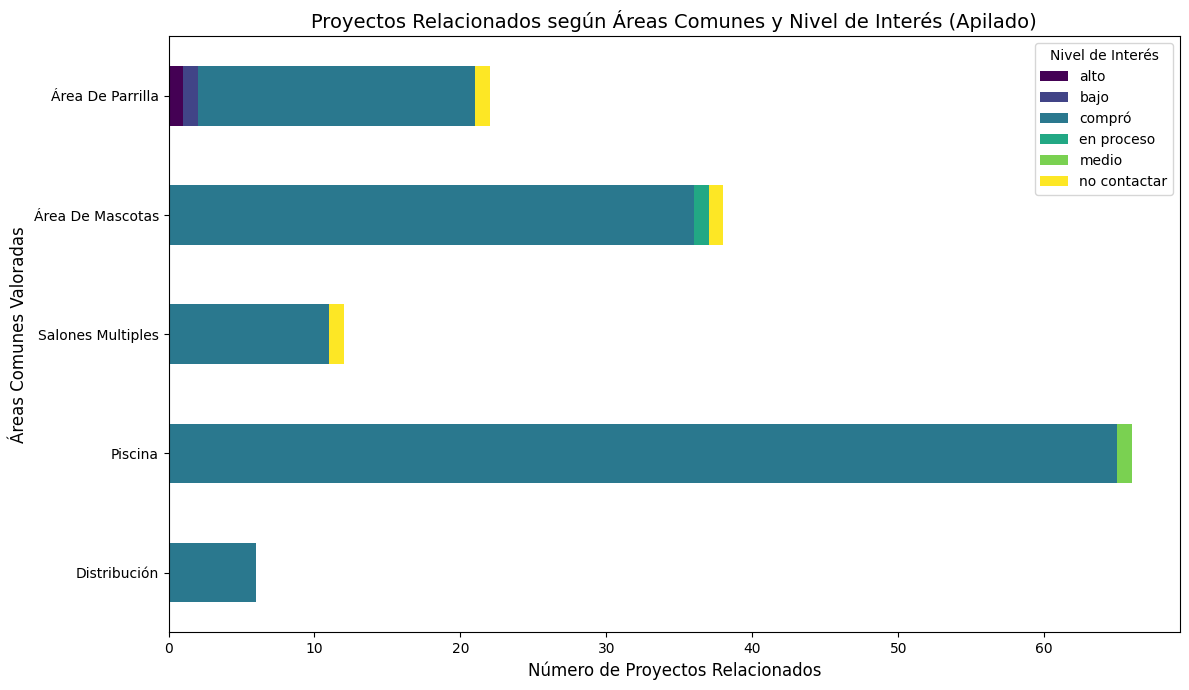

In [205]:
# Reestructura los datos para graficarlos en un grafico de barras apiladas
conteo_pivot = conteo.pivot(
    index="que_le_gusto_de_las_areas_comunes",
    columns="Nivel De Interes",
    values="Proyectos Relacionados"
).fillna(0)

# Gráfico de barras apiladas
conteo_pivot.plot(
    kind="barh",
    stacked=True,
    figsize=(12,7),
    colormap="viridis"
)

plt.title("Proyectos Relacionados según Áreas Comunes y Nivel de Interés (Apilado)", fontsize=14)
plt.xlabel("Número de Proyectos Relacionados", fontsize=12)
plt.ylabel("Áreas Comunes Valoradas", fontsize=12)
plt.legend(title="Nivel de Interés")
plt.tight_layout()
plt.show()

In [206]:
# Variable que contiene los valores de los datos graficados
conteo

,que_le_gusto_de_las_areas_comunes,Nivel De Interes,Proyectos Relacionados
0,Distribución,compró,6
1,Piscina,compró,65
2,Piscina,medio,1
3,Salones Multiples,compró,11
4,Salones Multiples,no contactar,1
5,Área De Mascotas,compró,36
6,Área De Mascotas,en proceso,1
7,Área De Mascotas,no contactar,1
8,Área De Parrilla,alto,1
9,Área De Parrilla,bajo,1


3. AREA SOCIAL MAS VALORADA VS PROYECTOS RELACIONADOS EN BASE A LOS PROYECTOS RELACIONADOS

In [207]:
# Se visualiza los valores unicos de la columna "Área Social más valorada. ¿Por qué? "
df["Área Social más valorada. ¿Por qué? "].unique()

array([nan, 'piscina', 'pet zone ', 'TODAS', 'Zona Pet', 'PARRILLAS',
       'Diversidad ', 'PISCINA', 'Area parrilla', 'Piscina y longue bar',
       'Piscina', 'zona pet y gimnasio ', 'LA PISCINA ', 'NINGUNA',
       'rooftop', 'zona  mascotas',
       'area de mascota , tengo mi perrito que es como mi hijo',
       'zona play por sus hijois ', 'ZONA PET',
       'PISCINA Y ZONA DE PARRILLAS', 'Piscina , Zona pet',
       'ZONA DE PARRILLAS ',
       'Zona Pet, porque tiene un sentido emocional.', 'Cat zone',
       'terraza', 'ZONA DE PARRILLAS', 'Gimnasio porque lo uso más',
       'Pisicna', 'PISCINA Y PARQUE INTERNO (OASIS)',
       'ZONA DE PARILLAS Y CO-WORKING', 'PISCINA Y ZONA DE PARRILLA',
       'mascotas', 'Zona de juegos', 'zona lounge y piscina',
       'ZONA DE MASCOTAS', ' Pet Friendly', 'MASCOTAS',
       'pet shower y piscina', 'zona de parrillas',
       'GATITOS, POR LA CALIDAD DE VIDA DE SUS MASCOTITAS', 'piscina ',
       'PISCINA MUY ELEGANTE', 'PISCINA Y ZONA D

In [208]:
# Debido a que algunos valores de la columna "Área Social más valorada. ¿Por qué? " se repiten con una ortografía distinta. Se agrupa estos valores y se almacenan en un diccionario
mapping = {
    "Piscina": [
        "piscina", "Piscina", "PISCINA", "Pisicna", "piscina ", "LA PISCINA",
        "Piscina y longue bar", "zona lounge y piscina", "PISCINA Y ZONA DE PARRILLAS",
        "PISCINA Y PARQUE INTERNO", "PISCINA Y ZONA DE PARRILLA",
        "pet shower y piscina", "PISCINA MUY ELEGANTE", "PISCINA Y ZONA DE MASCOTAS",
        "zona para niños pequeños y piscina", "Sala de niños y la piscina",
        "SPA PARA MASCOTA, GINMASIO Y PISCINA", "piscina y gimnasio",
        "sky deck , piscina.", "piscina y zona  de parrillas",
        "PISCINA, COWORKING", "zona pet y gimnasio "
    ],
    "Parrilla": [
        "PARRILLAS", "Area parrilla", "ZONA DE PARRILLAS", "ZONA DE PARRILLAS ",
        "ZONA DE PARILLAS Y CO-WORKING", "ZONA DE PARRILLA", "zona de parrillas",
        "zona  de parrillas", "LA ZONA DE PARRILLAS", "Parrilla",
        "Parrilla, le gusta hacer parrillas.", "La Zona de parrillas por el bar.",
        "zona  de parrillas y coworking privado", "AREA DE PARRILLAS",
        "Gym y zona  de parrillas"
    ],
    "Mascotas": [
        "Pet zone", "Zona Pet", "zona  mascotas", "area de mascota , tengo mi perrito que es como mi hijo",
        "ZONA PET", "Zona Pet, porque tiene un sentido emocional.", "Cat zone",
        "mascotas", "ZONA DE MASCOTAS", "Pet Friendly", "MASCOTAS", "zona de mascotas",
        "zona pet", "Pet´s Spa", "PARRILLA Y ZONA DE MASCOTAS", "ZONA CAT",
        "SPA PARA MASCOTA, GINMASIO Y PISCINA", "PARQUE DE GATOS",
        "PISCINA Y ÁREA DE MASCOTAS", "GATITOS, POR LA CALIDAD DE VIDA DE SUS MASCOTITAS",
        "GATITOS, GYM", "MASCOTAS ", "PET SPA", "mascota"
    ],
    "Gimnasio": [
        "Gimnasio", "Gimnasio ", "Gimnasio porque lo uso más", "zona pet y gimnasio ",
        "SPA PARA MASCOTA, GINMASIO Y PISCINA", "GATITOS, GYM"
    ],
    "Terraza / Rooftop": [
        "rooftop", "terraza", "Terraza"
    ],
    "Coworking": [
        "CO WORKING", "zona  de parrillas y coworking privado",
        "PISCINA, COWORKING", "ZONA DE PARILLAS Y CO-WORKING"
    ],
    "Niños": [
        "zona play por sus hijois", "zona para niños pequeños y piscina",
        "Sala de niños y la piscina", "Zona de juegos"
    ],
    "Parques / Áreas Verdes": [
        "Parque interior", "PISCINA Y PARQUE INTERNO (OASIS)", "PARQUE DE GATOS"
    ],
    "Otros": [
        "TODAS", "Diversidad", "NINGUNA", "ZONAS MULTIPLES"
    ]
}


In [209]:
# Se ejecuta la función "simplificar_categoria" para reducir la cantidad de valores de la columna "Área Social más valorada. ¿Por qué? " y se considera los usuarios que no dieron respuesta.
def simplificar_categoria(valor):
    if pd.isna(valor):
        return "Sin Respuesta"
    for key, valores in mapping.items():
        if any(v.lower().strip() in str(valor).lower().strip() for v in valores):
            return key
    return "Otros"
# Los valores simplificados se almacenan en df["Área Simplificada"]
df["Área Simplificada"] = df["Área Social más valorada. ¿Por qué? "].apply(simplificar_categoria)

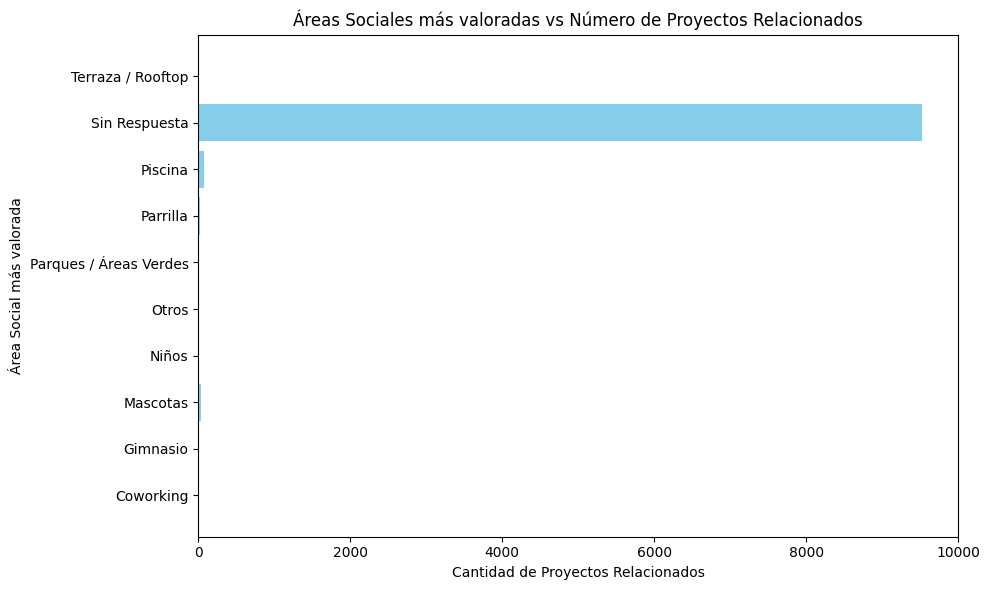

In [210]:
# Luego se agrupa por Área Simplificada y se cuenta los proyectos relacionados
conteo_proyectos = df.groupby("Área Simplificada")["Proyectos Relacionados"].count().reset_index()
conteo_proyectos = conteo_proyectos.rename(columns={"Proyectos Relacionados": "Cantidad de Proyectos"})

# Se grafica los datos agrupados
plt.figure(figsize=(10, 6))
plt.barh(conteo_proyectos["Área Simplificada"], conteo_proyectos["Cantidad de Proyectos"], color="skyblue")
plt.xlabel("Cantidad de Proyectos Relacionados")
plt.ylabel("Área Social más valorada")
plt.title("Áreas Sociales más valoradas vs Número de Proyectos Relacionados")
plt.tight_layout()
plt.show()

In [131]:
# Se visualiza los datos agrupados considerando los usuarios que no brindaron una respuesta.
conteo_proyectos

,Área Simplificada,Cantidad de Proyectos
0,Coworking,1
1,Gimnasio,5
2,Mascotas,31
3,Niños,2
4,Otros,7
5,Parques / Áreas Verdes,1
6,Parrilla,18
7,Piscina,76
8,Sin Respuesta,9527
9,Terraza / Rooftop,4


In [211]:
# Se ejecuta la función "simplificar_categoria" para reducir la cantidad de valores de la columna "Área Social más valorada. ¿Por qué? " sin considerar los usuarios que no dieron respuesta.
def simplificar_categoria(valor):
    if pd.isna(valor):
        return None   # No guardamos "Sin Respuesta"
    for key, valores in mapping.items():
        if any(v.lower().strip() in str(valor).lower().strip() for v in valores):
            return key
    return "Otros"

# Los valores simplificados se almacenan en df["Área Simplificada"]
df["Área Simplificada"] = df["Área Social más valorada. ¿Por qué? "].apply(simplificar_categoria)

# Eliminar filas donde la categoría sea None
df = df.dropna(subset=["Área Simplificada"]).reset_index(drop=True)

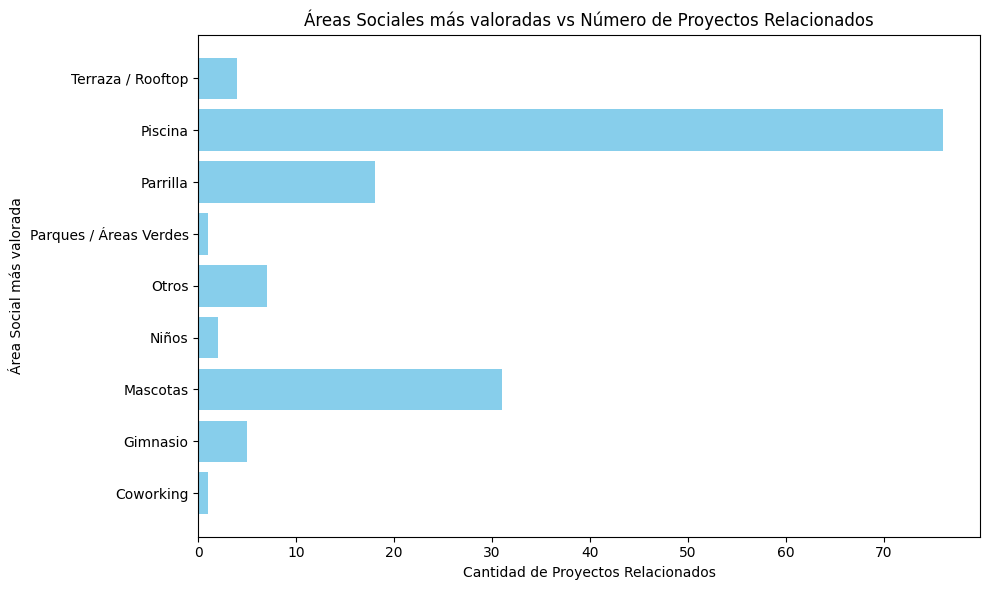

In [212]:
# Luego se agrupa por Área Simplificada y se cuenta los proyectos relacionados
conteo_proyectos = df.groupby("Área Simplificada")["Proyectos Relacionados"].count().reset_index()
conteo_proyectos = conteo_proyectos.rename(columns={"Proyectos Relacionados": "Cantidad de Proyectos"})

# Se grafica los datos agrupados
plt.figure(figsize=(10, 6))
plt.barh(conteo_proyectos["Área Simplificada"], conteo_proyectos["Cantidad de Proyectos"], color="skyblue")
plt.xlabel("Cantidad de Proyectos Relacionados")
plt.ylabel("Área Social más valorada")
plt.title("Áreas Sociales más valoradas vs Número de Proyectos Relacionados")
plt.tight_layout()
plt.show()

In [213]:
# Se visualiza los datos agrupados sin considerar los usuarios que no brindaron una respuesta.
conteo_proyectos

,Área Simplificada,Cantidad de Proyectos
0,Coworking,1
1,Gimnasio,5
2,Mascotas,31
3,Niños,2
4,Otros,7
5,Parques / Áreas Verdes,1
6,Parrilla,18
7,Piscina,76
8,Terraza / Rooftop,4


4. NIVEL DE INGRESOS VS NIVEL DE INTERES EN BASE AL PERFIL DEL CLIENTE

In [214]:
df["¿Cual es su sueldo promedio?"].unique()

array(['4552', '7,000', '7000', 'S/4000', '3500', 'S/8,700',
       'S/ 16,750.93 ', '14,000', '9500', '2,700', '2000', '10,000.00',
       '3000', '7500', '8,976.00', 'S/9,000.00', '10,000', '4000',
       '14,500', '22,000', '3,000', '2500', '17000', '4,000', '6200',
       '4500', '7100', '13000', '3,520', 'No indica', '30,000', '4MIL',
       '8,000', '5280 SOLES', '10400', '4,300', '5 mil ', nan, '6000',
       'NO DESEA DAR', '5900', '5000', '15000', '4,200', '6,000',
       'ninguno ', 'S/3,000.00', '7800', '3,200', 'No aplica', '5500',
       '5,500', '800', '8 mil soles', '6,500', '2000 ', '10000', '14000',
       '5,000', '4300', '6600', '2,000', '4,500', '7700', 'USD 12,000',
       'no especifica', '7,000 ', '7200', '8600', '6800', '9600',
       'si, 8,000', '8.500', '5100', '8,000 SOLES', '2.800', '-', '3700',
       '3200', '2,300', '4200', '5300', '20,000.00', '11,000'],
      dtype=object)

/tmp/ipython-input-3131626139.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Rango_Sueldo", "Nivel De Interes", "Genero"])


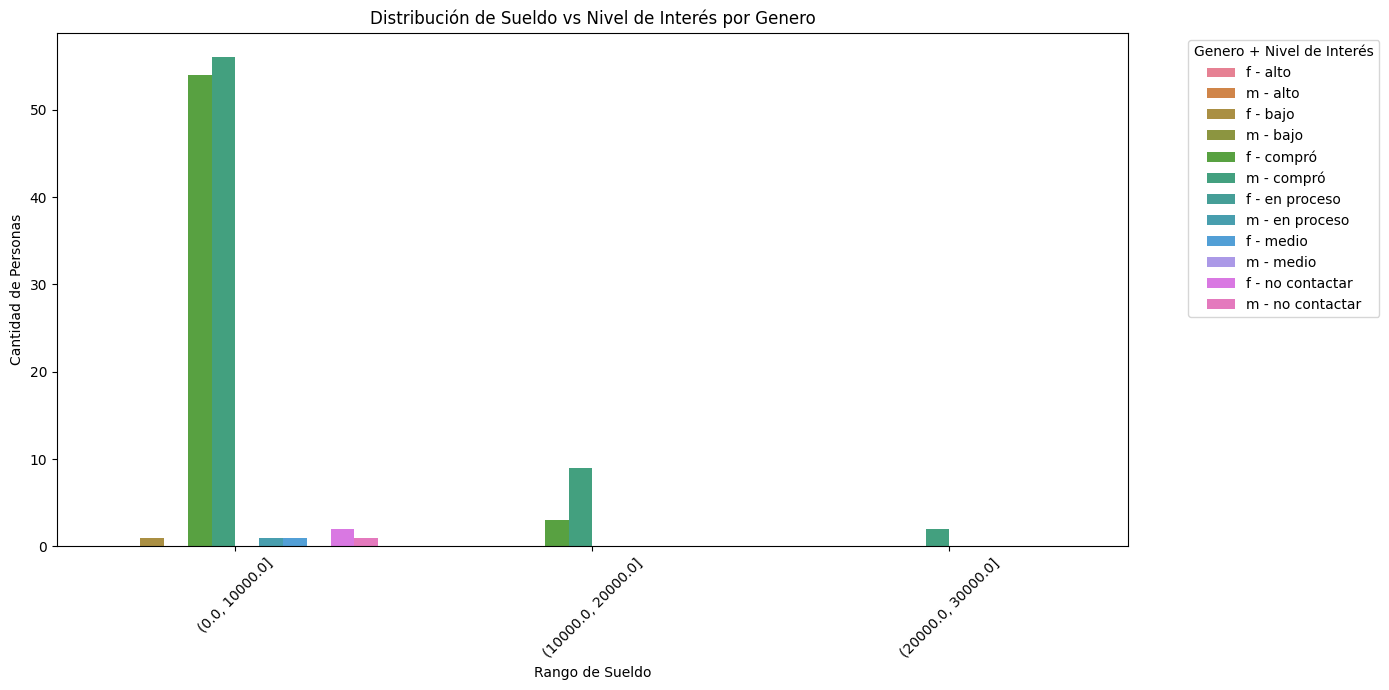

In [217]:
# Modifica los datos para que todos esten en valores numericos
def limpiar_sueldo(valor):
    if pd.isna(valor):
        return np.nan
    valor_str = str(valor).strip().lower()
    if any(x in valor_str for x in ["no", "ninguno", "-", "usd"]):
        return np.nan
    valor_str = valor_str.replace("mil", "000")
    valor_str = re.sub(r"[^\d.]", "", valor_str)
    if valor_str == "":
        return np.nan
    try:
        return float(valor_str)
    except:
        return np.nan

df["Sueldo_Num"] = df["¿Cual es su sueldo promedio?"].apply(limpiar_sueldo)

# Se establece un rango de sueldo en 10000 soles
max_sueldo = df["Sueldo_Num"].max()
bins = np.arange(0, max_sueldo + 10000, 10000)
df["Rango_Sueldo"] = pd.cut(df["Sueldo_Num"], bins=bins, right=True)

# Se agrupa el rango de sueldo con el nivel de interes en base al genero del usuario
conteo_nivel_ingresos = (
    df.groupby(["Rango_Sueldo", "Nivel De Interes", "Genero"])
    .size()
    .reset_index(name="Cantidad")
)

# Combina la columna Genero y Nivel de Interes y a almacena en conteo_nivel_ingresos["Grupo"]
conteo_nivel_ingresos["Grupo"] = conteo_nivel_ingresos["Genero"].astype(str) + " - " + conteo_nivel_ingresos["Nivel De Interes"].astype(str)

# Se grafica los datos
plt.figure(figsize=(14, 7))
sns.barplot(
    data=conteo_nivel_ingresos,
    x="Rango_Sueldo",
    y="Cantidad",
    hue="Grupo"
)

plt.xlabel("Rango de Sueldo")
plt.ylabel("Cantidad de Personas")
plt.title("Distribución de Sueldo vs Nivel de Interés por Genero")
plt.legend(title="Genero + Nivel de Interés", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [218]:
# Se visualiza los datos agrupados
conteo_nivel_ingresos

,Rango_Sueldo,Nivel De Interes,Genero,Cantidad,Grupo
0,"(0.0, 10000.0]",alto,f,0,f - alto
1,"(0.0, 10000.0]",alto,m,0,m - alto
2,"(0.0, 10000.0]",bajo,f,1,f - bajo
3,"(0.0, 10000.0]",bajo,m,0,m - bajo
4,"(0.0, 10000.0]",compró,f,54,f - compró
5,"(0.0, 10000.0]",compró,m,56,m - compró
6,"(0.0, 10000.0]",en proceso,f,0,f - en proceso
7,"(0.0, 10000.0]",en proceso,m,1,m - en proceso
8,"(0.0, 10000.0]",medio,f,1,f - medio
9,"(0.0, 10000.0]",medio,m,0,m - medio


5. CANAL DE ENTRADA VS NIVEL DE INTERES EN BASE A NIVEL DE INTERES

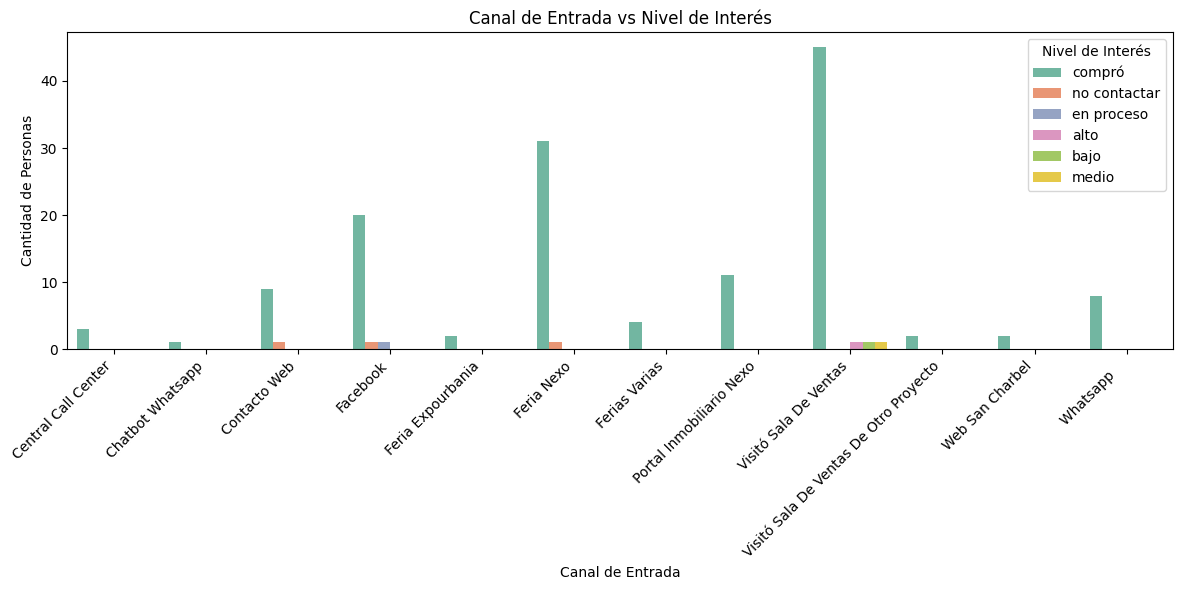

In [219]:
# Agrupamos los datos por Canal de Entrada y Nivel de Interés
conteo_canal_entrada = df.groupby(["Canal De Entrada", "Nivel De Interes"]).size().reset_index(name="Cantidad")

plt.figure(figsize=(12, 6))

# Gráfica de barras agrupadas
sns.barplot(
    data=conteo_canal_entrada,
    x="Canal De Entrada",
    y="Cantidad",
    hue="Nivel De Interes",
    palette="Set2"
)

plt.title("Canal de Entrada vs Nivel de Interés")
plt.xlabel("Canal de Entrada")
plt.ylabel("Cantidad de Personas")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nivel de Interés")
plt.tight_layout()
plt.show()

In [220]:
# Se visualiza los datos agrupados
conteo_canal_entrada

,Canal De Entrada,Nivel De Interes,Cantidad
0,Central Call Center,compró,3
1,Chatbot Whatsapp,compró,1
2,Contacto Web,compró,9
3,Contacto Web,no contactar,1
4,Facebook,compró,20
5,Facebook,en proceso,1
6,Facebook,no contactar,1
7,Feria Expourbania,compró,2
8,Feria Nexo,compró,31
9,Feria Nexo,no contactar,1
